# **SETUP**

## *LIBRARIES*

In [1]:
!pip install lime --quiet


import io
import json
import math
import os
import re
import sys
import time
import warnings
from collections import defaultdict
from datetime import datetime

import gdown
import joblib
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import shap
import shap.explainers._tree as tree_module
import xgboost
from google.colab import drive, files
from imblearn.metrics import specificity_score
from IPython.display import HTML, display
from lightgbm import LGBMClassifier
from mlxtend.plotting import plot_confusion_matrix
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (
    LogisticRegression,
    LogisticRegressionCV,
    PassiveAggressiveClassifier,
    Perceptron,
    RidgeClassifier,
    RidgeClassifierCV,
    SGDClassifier,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.svm import LinearSVC, NuSVC, SVC
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.utils import shuffle
from xgboost import XGBClassifier


seed = 42
malicious_ratio = 0.3
train_test_split_ratio = 0.7
sample_fraction = 1


def adjust_train_test_ratio(train_df, test_df, train_ratio):
    train_shuffled = train_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    test_shuffled = test_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    current_train_size = len(train_shuffled)
    current_test_size = len(test_shuffled)
    current_ratio = current_train_size / (current_train_size + current_test_size)

    if current_ratio > train_ratio:
        final_train_size = int(current_test_size * train_ratio / (1 - train_ratio))
        new_train = train_shuffled.iloc[:final_train_size].copy()
        new_test = test_shuffled.copy()
    elif current_ratio < train_ratio:
        final_test_size = int(current_train_size * (1 - train_ratio) / train_ratio)
        new_train = train_shuffled.copy()
        new_test = test_shuffled.iloc[:final_test_size].copy()
    else:
        new_train = train_shuffled.copy()
        new_test = test_shuffled.copy()

    actual_total = len(new_train) + len(new_test)
    actual_train_ratio = len(new_train) / actual_total
    print(f"Total samples: {actual_total}")
    print(f"Train samples: {len(new_train)} ({len(new_train)/actual_total*100:.1f}%)")
    print(f"Test samples: {len(new_test)} ({len(new_test)/actual_total*100:.1f}%)")
    print(f"Achieved ratio: {actual_train_ratio:.2f} / {1-actual_train_ratio:.2f}")

    return new_train, new_test


def balance_single_dataset(df, malicious_ratio):
    malicious = df[df['label'] == 1].copy()
    benign = df[df['label'] == 0].copy()

    n_malicious = len(malicious)
    n_benign = len(benign)

    needed_benign = int(n_malicious * (1 - malicious_ratio) / malicious_ratio)

    if needed_benign <= n_benign:
        final_malicious = n_malicious
        final_benign = needed_benign
    else:
        final_benign = n_benign
        final_malicious = int(n_benign * malicious_ratio / (1 - malicious_ratio))
        final_malicious = min(final_malicious, n_malicious)

    malicious_sampled = malicious.sample(n=final_malicious, random_state=seed)
    benign_sampled = benign.sample(n=final_benign, random_state=seed)

    balanced = pd.concat([malicious_sampled, benign_sampled], ignore_index=True)
    balanced = balanced.sample(frac=1, random_state=seed).reset_index(drop=True)

    return balanced


def adjust_label_distribution(train_df, test_df, malicious_ratio=0.5):
    train_balanced = balance_single_dataset(train_df, malicious_ratio)
    test_balanced = balance_single_dataset(test_df, malicious_ratio)

    train_mal = int(train_balanced['label'].sum())
    train_ben = int((train_balanced['label'] == 0).sum())
    test_mal = int(test_balanced['label'].sum())
    test_ben = int((test_balanced['label'] == 0).sum())

    print(f"Train - Total: {len(train_balanced)}, Malicious: {train_mal}, Benign: {train_ben}")
    print(f"Test - Total: {len(test_balanced)}, Malicious: {test_mal}, Benign: {test_ben}")
    print(f"Train - Malicious: {train_mal / len(train_balanced) * 100:.1f}%")
    print(f"Test - Malicious: {test_mal / len(test_balanced) * 100:.1f}%")

    return train_balanced, test_balanced


print(f"XGBOOST: {xgboost.__version__}")
print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
XGBOOST: 3.2.0
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
NumPy: 2.0.2


## *FETCH*

In [2]:
csv_dir = "/content/csv"
os.makedirs(csv_dir, exist_ok=True)

folder_id = '1mZLco7DwN_MmVm-kf78-lYN1XyZdEsJj'

print("Downloading CSV files...")
gdown.download_folder(
    f'https://drive.google.com/drive/folders/{folder_id}',
    output=csv_dir,
    quiet=True,
    use_cookies=False
)


print("\nCSV files downloaded:")
for filename in os.listdir(csv_dir):
    filepath = os.path.join(csv_dir, filename)
    size_bytes = os.path.getsize(filepath)
    size_mb = size_bytes / (1024 * 1024)
    print(f"  {filename}: {size_bytes:,} bytes ({size_mb:.2f} MB)")

train_df = pd.read_csv(os.path.join(csv_dir, 'window_features_train.csv'))
test_df = pd.read_csv(os.path.join(csv_dir, 'window_features_test.csv'))

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")

csv_files = [f for f in os.listdir(csv_dir) if f.endswith(".csv")]

train_csv = [f for f in csv_files if 'train' in f][0]
test_csv = [f for f in csv_files if 'test' in f][0]




CSV files downloaded:
  session_2_16HR: 4,096 bytes (0.00 MB)
  session_1_32HR: 4,096 bytes (0.00 MB)
  window_features_train.csv: 13,643,091 bytes (13.01 MB)
  window_features_test.csv: 6,823,800 bytes (6.51 MB)

Train rows: 45928
Test rows: 22966


# **DATA-PREPROCESSING**

## *ENCODING / DATA TREATMENT*

In [3]:
train_df = pd.read_csv(os.path.join(csv_dir, train_csv))
test_df = pd.read_csv(os.path.join(csv_dir, test_csv))
test_attack_type_raw = pd.read_csv(os.path.join(csv_dir, test_csv))['attack_type']

print(f"Train DataFrame shape: {train_df.shape}")
print(f"Test DataFrame shape: {test_df.shape}")

dfs = [train_df, test_df]

for i, df in enumerate(dfs):
    if 'label' in df.columns:
        df['label'] = df['label'].map({'benign': 0, 'malicious': 1})

    if 'namespace' in df.columns:
        namespace_encoded = pd.get_dummies(df['namespace'], prefix='namespace')
        df = pd.concat([df, namespace_encoded], axis=1)
        df = df.drop(columns=['namespace'])

    dfs[i] = df
    print(df.shape)

train_df = dfs[0]
test_df = dfs[1]

Train DataFrame shape: (45928, 32)
Test DataFrame shape: (22966, 32)
(45928, 33)
(22966, 33)


## *FEATURES*

In [4]:
print("\nDataFrame features:")
print(f"\nFeatures before selection: {len(train_df.columns)}")
print(train_df.columns)


features_to_keep = [
    'n_total',                      # Total operation count
    'operations_per_second',        # Average rate
    'max_ops_per_second',          # Peak burst rate
    'operation_mix_add',           # % of adds
    'operation_mix_remove',        # % of removes
    'operation_mix_update',        # % of updates
    'keys_affected',               # NEW: Breadth of attack
    # 'inter_op_std',                # Timing irregularity
    # 'inter_op_cv',                 # Relative timing variation
    # 'lag1_autocorr',               # NEW: Sequential dependency
    'clustering_score',            # Temporal clustering
    'spectral_entropy',            # Frequency domain complexity
    'burst_operations',            # Burst indicator
    'burst_count',                 # Number of bursts
]

# ['window_duration', 'n_adds', 'n_removes', 'n_updates', 'n_total',
#        'keys_affected', 'unique_prefixes', 'churn_rate', 'operation_mix_add',
#        'operation_mix_remove', 'operation_mix_update', 'cross_namespace_ops',
#        'isolation_score', 'burst_operations', 'attack_ops', 'benign_ops',
#        'attack_ratio', 'is_attack', 'attack_type', 'operations_per_second',
#        'update_dominance', 'churn_rate_zscore', 'inter_op_mean',
#        'inter_op_std', 'inter_op_cv', 'lag1_autocorr', 'clustering_score',
#        'max_ops_per_second', 'burst_count', 'spectral_entropy', 'label',
#        'namespace_xappsdl', 'namespace_xappsdlmalicioso']

train_df = train_df[features_to_keep + ['label']]
test_df = test_df[features_to_keep + ['label']]

print(f"\nFeatures after selection: {len(features_to_keep)}")
print(f"Selected features: {features_to_keep}")


DataFrame features:

Features before selection: 33
Index(['window_duration', 'n_adds', 'n_removes', 'n_updates', 'n_total',
       'keys_affected', 'unique_prefixes', 'churn_rate', 'operation_mix_add',
       'operation_mix_remove', 'operation_mix_update', 'cross_namespace_ops',
       'isolation_score', 'burst_operations', 'attack_ops', 'benign_ops',
       'attack_ratio', 'is_attack', 'attack_type', 'operations_per_second',
       'update_dominance', 'churn_rate_zscore', 'inter_op_mean',
       'inter_op_std', 'inter_op_cv', 'lag1_autocorr', 'clustering_score',
       'max_ops_per_second', 'burst_count', 'spectral_entropy', 'label',
       'namespace_xappsdl', 'namespace_xappsdlmalicioso'],
      dtype='object')

Features after selection: 11
Selected features: ['n_total', 'operations_per_second', 'max_ops_per_second', 'operation_mix_add', 'operation_mix_remove', 'operation_mix_update', 'keys_affected', 'clustering_score', 'spectral_entropy', 'burst_operations', 'burst_count']


## *BALANCING*

In [5]:
if sample_fraction < 1.0:
    train_df = train_df.sample(frac=sample_fraction, random_state=42).reset_index(drop=True)
    test_df = test_df.sample(frac=sample_fraction, random_state=42).reset_index(drop=True)

train_df, test_df = adjust_train_test_ratio(train_df, test_df, train_test_split_ratio)

train_df, test_df = adjust_label_distribution(train_df, test_df, malicious_ratio)

x_train = train_df.drop(columns=['label'])
y_train = train_df['label']

x_test = test_df.drop(columns=['label'])
y_test = test_df['label']

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
test_attack_types = test_attack_type_raw.iloc[test_df.index].reset_index(drop=True)


print(f"\n{'='*80}")
print("DATA PREPARATION SUMMARY")
print(f"{'='*80}")

print(f"\nDataset: Train={len(x_train):,} ({len(x_train)/(len(x_train)+len(x_test))*100:.1f}%), "
      f"Test={len(x_test):,} ({len(x_test)/(len(x_train)+len(x_test))*100:.1f}%), "
      f"Features={x_train.shape[1]}")

train_labels = y_train.value_counts().sort_index()
test_labels = y_test.value_counts().sort_index()

print(f"\nLabel Distribution:")
print(f"  {'':8} {'Train':>15} {'Test':>15}")
print(f"  {'-'*40}")
for label in sorted(set(train_labels.index) | set(test_labels.index)):
    label_name = "Malicious" if label == 1 else "Benign"
    train_cnt = train_labels.get(label, 0)
    test_cnt = test_labels.get(label, 0)
    train_pct = train_cnt / len(y_train) * 100
    test_pct = test_cnt / len(y_test) * 100
    print(f"  {label_name:8} {train_cnt:>7,} ({train_pct:5.1f}%) {test_cnt:>7,} ({test_pct:5.1f}%)")

if len(train_labels) == 2:
    train_ratio = train_labels.get(0, 0) / train_labels.get(1, 1) if train_labels.get(1, 0) > 0 else 0
    test_ratio = test_labels.get(0, 0) / test_labels.get(1, 1) if test_labels.get(1, 0) > 0 else 0
    print(f"\nClass Balance (Benign:Malicious): Train={train_ratio:.2f}:1, Test={test_ratio:.2f}:1")


print(f"\nTest Set Attack Types:")
attack_counts = test_attack_types.value_counts()
print(f"  {'Attack Type':<35} {'Count':>10} {'%':>8}")
print(f"  {'-'*55}")
for attack_type, count in attack_counts.items():
    pct = count / len(test_attack_types) * 100
    print(f"  {str(attack_type):<35} {count:>10,} {pct:>7.2f}%")
print(f"  {'-'*55}")
print(f"  Total: {len(attack_counts)} unique types, {len(test_attack_types):,} samples")

Total samples: 65611
Train samples: 45928 (70.0%)
Test samples: 19683 (30.0%)
Achieved ratio: 0.70 / 0.30
Train - Total: 27776, Malicious: 8333, Benign: 19443
Test - Total: 12040, Malicious: 3612, Benign: 8428
Train - Malicious: 30.0%
Test - Malicious: 30.0%

DATA PREPARATION SUMMARY

Dataset: Train=27,776 (69.8%), Test=12,040 (30.2%), Features=11

Label Distribution:
                     Train            Test
  ----------------------------------------
  Benign    19,443 ( 70.0%)   8,428 ( 70.0%)
  Malicious   8,333 ( 30.0%)   3,612 ( 30.0%)

Class Balance (Benign:Malicious): Train=2.33:1, Test=2.33:1

Test Set Attack Types:
  Attack Type                              Count        %
  -------------------------------------------------------
  none                                     9,749   80.97%
  dos_fast                                   723    6.00%
  cache_poison                               651    5.41%
  dos_slow                                   567    4.71%
  exfiltration     

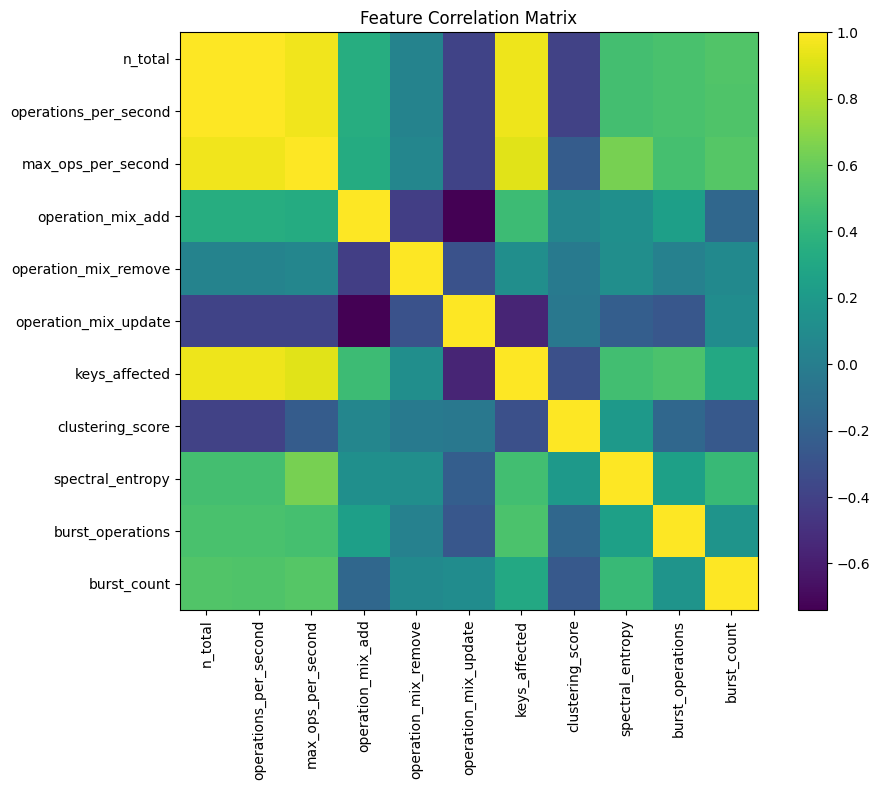


=== Feature Redundancy Analysis ===

 Feature 'n_total' shows high multicollinearity:
   • Strongly correlated (|ρ| ≥ 0.9) with 3 features:
     - operations_per_second
     - max_ops_per_second
     - keys_affected
   → This feature is potentially redundant and should be considered for exclusion.

 Feature 'operations_per_second' shows high multicollinearity:
   • Strongly correlated (|ρ| ≥ 0.9) with 3 features:
     - n_total
     - max_ops_per_second
     - keys_affected
   → This feature is potentially redundant and should be considered for exclusion.

 Feature 'max_ops_per_second' shows high multicollinearity:
   • Strongly correlated (|ρ| ≥ 0.9) with 3 features:
     - n_total
     - operations_per_second
     - keys_affected
   → This feature is potentially redundant and should be considered for exclusion.

 Feature 'keys_affected' shows high multicollinearity:
   • Strongly correlated (|ρ| ≥ 0.9) with 3 features:
     - n_total
     - operations_per_second
     - max_ops_per_s

In [6]:
df = train_df
df = df.drop(columns=["label"], errors="ignore")

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

corr_threshold = 0.90
min_connections = 3

abs_corr = corr.abs()
np.fill_diagonal(abs_corr.values, 0)

print("\n=== Feature Redundancy Analysis ===\n")

flag_found = False

for feature in abs_corr.columns:
    correlated = abs_corr.index[abs_corr[feature] >= corr_threshold].tolist()

    if len(correlated) >= min_connections:
        flag_found = True
        print(f" Feature '{feature}' shows high multicollinearity:")
        print(f"   • Strongly correlated (|ρ| ≥ {corr_threshold}) with {len(correlated)} features:")
        for f in correlated:
            print(f"     - {f}")
        print("   → This feature is potentially redundant and should be considered for exclusion.\n")

if not flag_found:
    print("No features exhibit strong multicollinearity under the current thresholds.")


# **Model training**

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,Kappa,Specificity,ROC_AUC
0,XGBClassifier,0.9885,0.9896,0.9718,0.9806,0.9724,0.9956,0.9975
1,GradientBoostingClassifier,0.9878,0.9923,0.9668,0.9794,0.9707,0.9968,0.9966
2,RandomForestClassifier,0.9871,0.9906,0.9662,0.9783,0.9691,0.9961,0.9964
3,BaggingClassifier,0.9865,0.9876,0.9673,0.9773,0.9678,0.9948,0.9923
4,ExtraTreesClassifier,0.9865,0.9870,0.9679,0.9774,0.9678,0.9945,0.9957
5,Support Vector Machines,0.9863,0.9980,0.9563,0.9767,0.9670,0.9992,0.9942
6,KNeighborsClassifier,0.9860,0.9968,0.9563,0.9761,0.9662,0.9987,0.9923
7,AdaBoostClassifier,0.9826,0.9835,0.9579,0.9705,0.9582,0.9931,0.9938
8,DecisionTreeClassifier,0.9792,0.9633,0.9676,0.9655,0.9506,0.9842,0.9759
9,ExtraTreeClassifier,0.9790,0.9667,0.9632,0.9649,0.9499,0.9858,0.9745


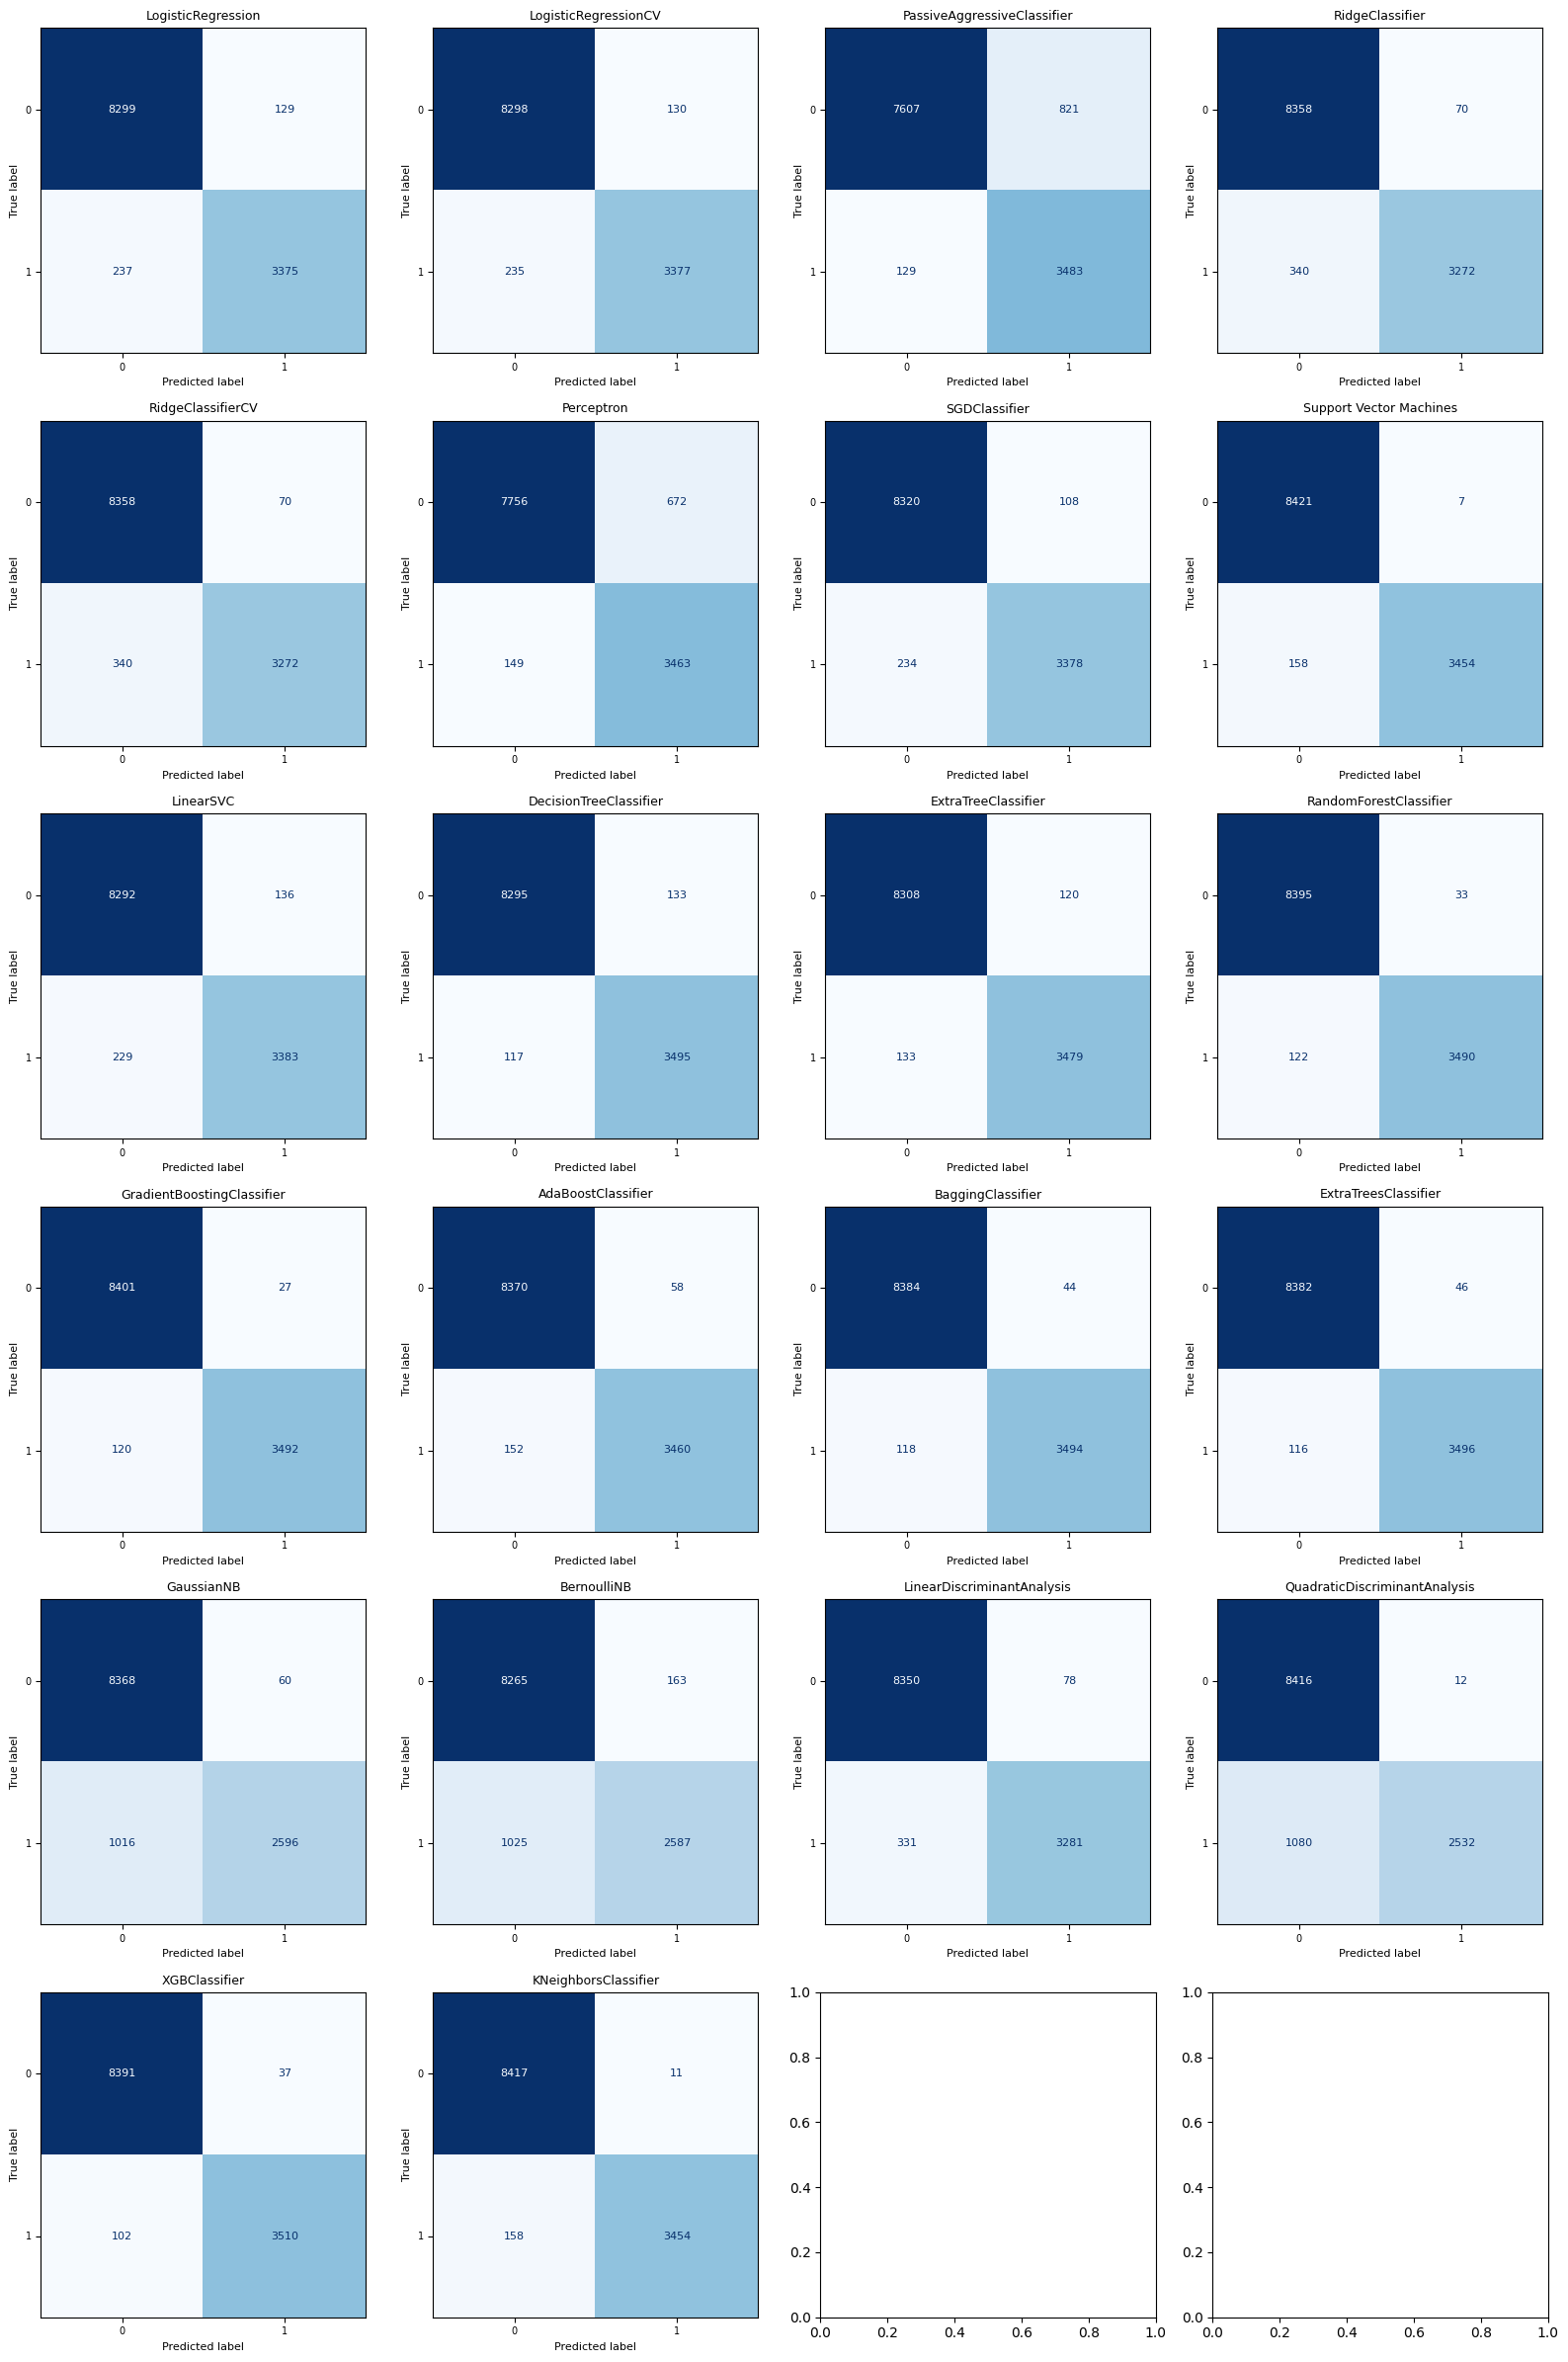

In [7]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'LogisticRegressionCV': LogisticRegressionCV(max_iter=1000),
    'PassiveAggressiveClassifier': PassiveAggressiveClassifier(),
    'RidgeClassifier': RidgeClassifier(),
    'RidgeClassifierCV': RidgeClassifierCV(),
    'Perceptron': Perceptron(),
    'SGDClassifier': SGDClassifier(),
    'Support Vector Machines': SVC(probability=True),
    'LinearSVC': LinearSVC(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'ExtraTreeClassifier': ExtraTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'BaggingClassifier': BaggingClassifier(),
    'ExtraTreesClassifier': ExtraTreesClassifier(),
    'GaussianNB': GaussianNB(),
    'BernoulliNB': BernoulliNB(),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
    'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(),
    'XGBClassifier': XGBClassifier(eval_metric='logloss'),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=10),
}


metrics_results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'Kappa': [],
    'Specificity': [],
    'ROC_AUC': []
}

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
    kappa = cohen_kappa_score(y_test, y_pred)

    if cm.shape == (2, 2):
        TN = cm[0, 0]
        FP = cm[0, 1]
        specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    else:
        specificity = float('nan')

    if hasattr(model, "predict_proba"):
        try:
            y_scores = model.predict_proba(x_test_scaled)[:, 1]
            roc_auc = roc_auc_score(y_test, y_scores)
        except Exception:
            roc_auc = float('nan')
    elif hasattr(model, "decision_function"):
        try:
            y_scores = model.decision_function(x_test_scaled)
            roc_auc = roc_auc_score(y_test, y_scores)
        except Exception:
            roc_auc = float('nan')
    else:
        roc_auc = float('nan')

    metrics_results['Model'].append(name)
    metrics_results['Accuracy'].append(accuracy)
    metrics_results['Precision'].append(precision)
    metrics_results['Recall'].append(recall)
    metrics_results['F1-Score'].append(f1)
    metrics_results['Kappa'].append(kappa)
    metrics_results['Specificity'].append(specificity)
    metrics_results['ROC_AUC'].append(roc_auc)

metrics_df = pd.DataFrame(metrics_results).round(4)
metrics_df = metrics_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(metrics_df)


n_models = len(models)
cols = 4
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(x_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False, values_format='d')


    axes[idx].set_title(f'{name}', fontsize=9)
    axes[idx].set_xlabel('Predicted label', fontsize=8)
    axes[idx].set_ylabel('True label', fontsize=8)
    axes[idx].tick_params(axis='both', which='major', labelsize=7)
    for text in axes[idx].texts:
        text.set_fontsize(8)

    axes[idx].grid(False)

plt.tight_layout()
plt.show()
plt.close(fig)


# **EXPORT**

In [8]:
EXPORT_DIR = "."
os.makedirs(EXPORT_DIR, exist_ok=True)

model_filename = os.path.join(EXPORT_DIR, 'xgb_model.joblib')
joblib.dump(models['XGBClassifier'], model_filename)
print(f"Model saved to {model_filename}")

scaler_filename = os.path.join(EXPORT_DIR, 'scaler.joblib')
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to {scaler_filename}")


feature_columns = list(x_train.columns)
print(f"\nFeature columns ({len(feature_columns)}):\n  {feature_columns}")


aux = pd.read_csv(os.path.join(csv_dir, 'window_features_train.csv'))

namespace_stats_export = {}
for namespace, grp in aux.groupby('namespace'):
    churn = grp['keys_affected'] / grp['window_duration'].replace(0, np.nan)
    churn = churn.fillna(0)
    std_val = float(churn.std()) if len(churn) > 1 else 1.0
    namespace_stats_export[str(namespace)] = {
        'churn_rate_mean': float(churn.mean()),
        'churn_rate_std':  std_val if std_val > 0 else 1.0,
    }
print(f"\nnamespace_stats:\n  {namespace_stats_export}")


known_namespaces = sorted(aux['namespace'].unique().tolist())
print(f"\nknown_namespaces: {known_namespaces}")

meta = {
    "namespace_stats":  namespace_stats_export,
    "known_namespaces": known_namespaces,
    "feature_columns":  feature_columns,
}

meta_path = os.path.join(EXPORT_DIR, "inference_meta.json")
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f"\ninference_meta.json saved to {meta_path}")
print(f"\nFiles to copy into MODEL_DIR on the xApp container:")
print(f"  xgb_model.joblib")
print(f"  scaler.joblib")
print(f"  inference_meta.json")

Model saved to ./xgb_model.joblib
Scaler saved to ./scaler.joblib

Feature columns (11):
  ['n_total', 'operations_per_second', 'max_ops_per_second', 'operation_mix_add', 'operation_mix_remove', 'operation_mix_update', 'keys_affected', 'clustering_score', 'spectral_entropy', 'burst_operations', 'burst_count']

namespace_stats:
  {'xappsdl': {'churn_rate_mean': 1.5955029332504396, 'churn_rate_std': 0.28639956221052476}, 'xappsdlmalicioso': {'churn_rate_mean': 2.671554007025392, 'churn_rate_std': 3.2024207245285754}}

known_namespaces: ['xappsdl', 'xappsdlmalicioso']

inference_meta.json saved to ./inference_meta.json

Files to copy into MODEL_DIR on the xApp container:
  xgb_model.joblib
  scaler.joblib
  inference_meta.json


# **ANALISYS**



✓ Float parser patched!

Top 10 important features based on SHAP values:
                  Feature  Mean |SHAP|
3       operation_mix_add     2.473794
0                 n_total     2.193593
1   operations_per_second     1.495303
2      max_ops_per_second     1.027035
8        spectral_entropy     0.755913
5    operation_mix_update     0.523092
4    operation_mix_remove     0.484365
6           keys_affected     0.436987
10            burst_count     0.298606
7        clustering_score     0.256636


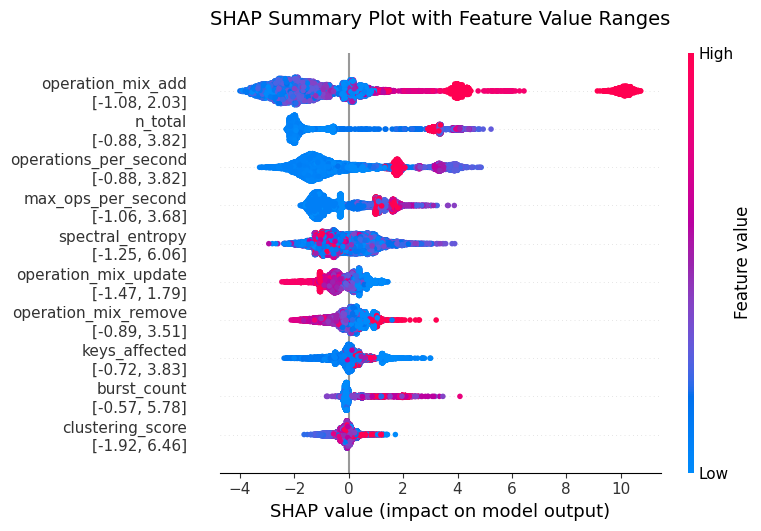

In [9]:
x_test_scaled = pd.DataFrame(
    x_test_scaled,
    columns=x_test.columns,
    index=x_test.index
)

original_float = float

def patched_float(value):
    """Patched float() that handles array-format strings"""
    if isinstance(value, str) and value.startswith('[') and value.endswith(']'):
        return original_float(value.strip('[]'))
    return original_float(value)


tree_module.float = patched_float

print("✓ Float parser patched!")


xgb_model = models['XGBClassifier']

explainer_shap = shap.TreeExplainer(xgb_model)


tree_module.float = original_float

shap_values = explainer_shap.shap_values(x_test_scaled)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': x_test_scaled.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values(by='Mean |SHAP|', ascending=False)

print("\nTop 10 important features based on SHAP values:")
print(importance_df.head(10))


top_10_features = importance_df.head(10)['Feature'].tolist()


feature_labels = []
for feature in top_10_features:
    if feature in x_test_scaled.columns:
        min_val = x_test_scaled[feature].min()
        max_val = x_test_scaled[feature].max()
        feature_labels.append(f'{feature}\n[{min_val:.2f}, {max_val:.2f}]')
    else:
        feature_labels.append(feature)


feature_labels = feature_labels[::-1]


plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=(16.8, 9.6))

shap.summary_plot(
    shap_values,
    x_test_scaled,
    plot_type="dot",
    color_bar=True,
    color="coolwarm",
    max_display=10,
    show=False
)


ax.set_yticklabels(feature_labels, fontsize=11)

plt.title('SHAP Summary Plot with Feature Value Ranges', pad=20, fontsize=14)
plt.tight_layout()
plt.show()

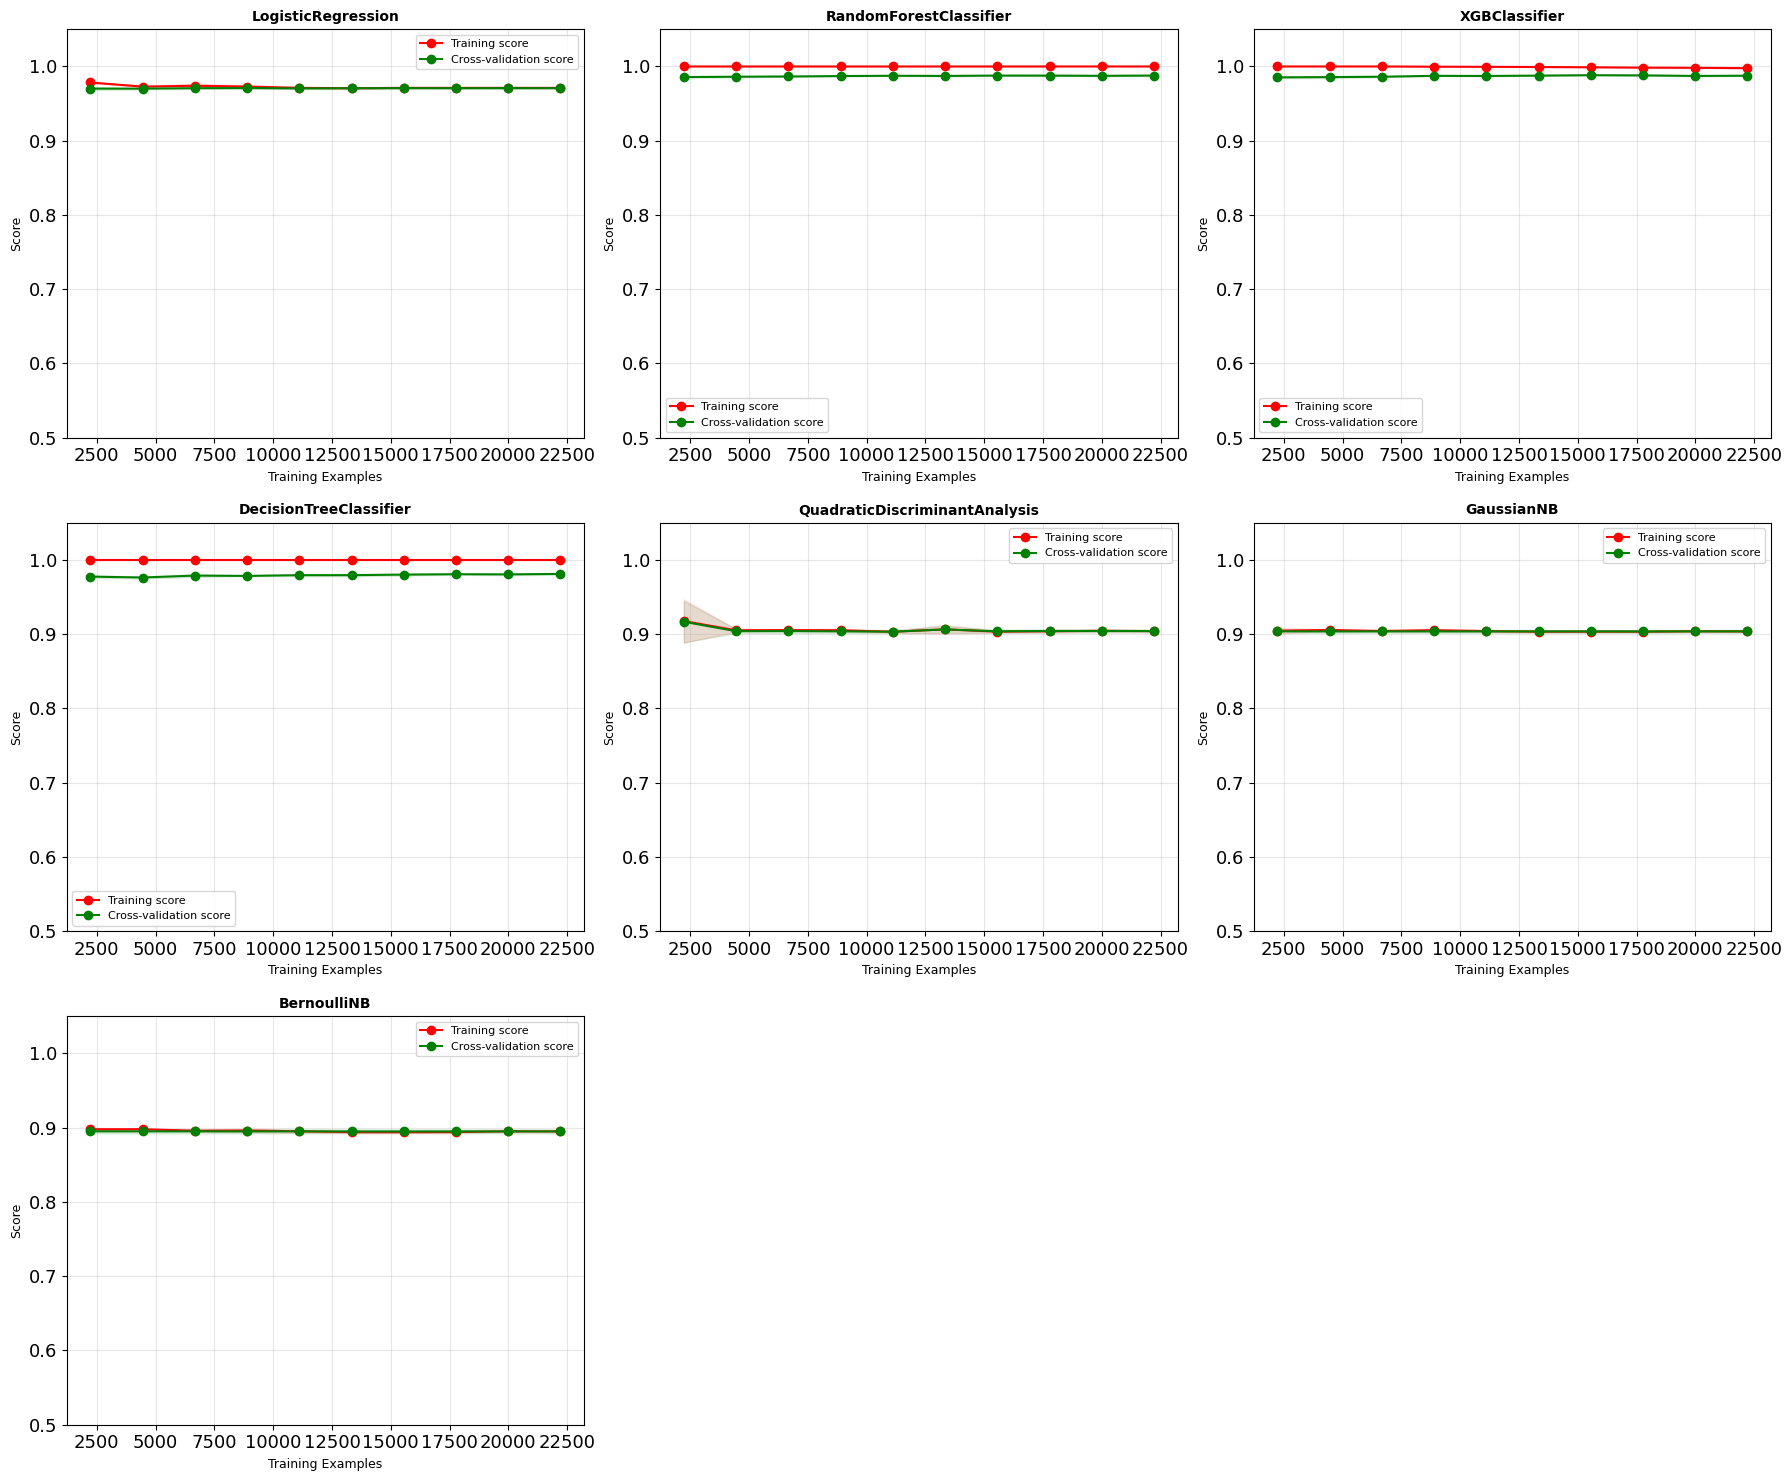

In [10]:
from sklearn.model_selection import learning_curve


selected_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForestClassifier': RandomForestClassifier(),
    'XGBClassifier': XGBClassifier(eval_metric='logloss'),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(),
    'GaussianNB': GaussianNB(),
    'BernoulliNB': BernoulliNB()
}


n_models = len(selected_models)
cols = 3
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

for idx, (name, model) in enumerate(selected_models.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        x_train_scaled,
        y_train,
        cv=5,  # 5-fold cross-validation
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),  # 10 points from 10% to 100% of training data
        scoring='accuracy',
        random_state=42
    )


    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    axes[idx].plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
    axes[idx].plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')

    axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                           alpha=0.1, color='r')
    axes[idx].fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                           alpha=0.1, color='g')

    axes[idx].set_title(f'{name}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Training Examples', fontsize=9)
    axes[idx].set_ylabel('Score', fontsize=9)
    axes[idx].legend(loc='best', fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0.5, 1.05])

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
plt.close(fig)

In [11]:

warnings.filterwarnings('ignore')


per_attack_records = []

unique_attacks = test_attack_types.unique()

x_test_scaled_np = x_test_scaled if isinstance(x_test_scaled, np.ndarray) else np.array(x_test_scaled)
y_test_np = np.array(y_test)

for name, model in models.items():
    y_pred_all = model.predict(x_test_scaled_np)

    if hasattr(model, "predict_proba"):
        try:
            y_scores_all = model.predict_proba(x_test_scaled_np)[:, 1]
        except Exception:
            y_scores_all = None
    elif hasattr(model, "decision_function"):
        try:
            y_scores_all = model.decision_function(x_test_scaled_np)
        except Exception:
            y_scores_all = None
    else:
        y_scores_all = None

    for attack in unique_attacks:
        mask = (test_attack_types == attack).values

        y_true_sub = y_test_np[mask]
        y_pred_sub = y_pred_all[mask]

        if len(y_true_sub) == 0:
            continue

        has_both_classes = len(np.unique(y_true_sub)) > 1

        accuracy  = accuracy_score(y_true_sub, y_pred_sub)
        precision = precision_score(y_true_sub, y_pred_sub, average='binary', zero_division=0)
        recall    = recall_score(y_true_sub, y_pred_sub, average='binary', zero_division=0)
        f1        = f1_score(y_true_sub, y_pred_sub, average='binary', zero_division=0)
        kappa     = cohen_kappa_score(y_true_sub, y_pred_sub) if has_both_classes else float('nan')

        cm = confusion_matrix(y_true_sub, y_pred_sub)
        if cm.shape == (2, 2):
            TN, FP = cm[0, 0], cm[0, 1]
            specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
        else:
            specificity = float('nan')

        if y_scores_all is not None and has_both_classes:
            try:
                roc_auc = roc_auc_score(y_true_sub, y_scores_all[mask])
            except Exception:
                roc_auc = float('nan')
        else:
            roc_auc = float('nan')

        per_attack_records.append({
            'Model':       name,
            'Attack_Type': attack,
            'N_Samples':   int(mask.sum()),
            'Accuracy':    round(accuracy,    4),
            'Precision':   round(precision,   4),
            'Recall':      round(recall,      4),
            'F1-Score':    round(f1,          4),
            'Kappa':       round(kappa,       4) if not np.isnan(kappa)        else float('nan'),
            'Specificity': round(specificity, 4) if not np.isnan(specificity)  else float('nan'),
            'ROC_AUC':     round(roc_auc,     4) if not np.isnan(roc_auc)      else float('nan'),
        })

per_attack_df = pd.DataFrame(per_attack_records)

for attack in sorted(unique_attacks):
    subset = (
        per_attack_df[per_attack_df['Attack_Type'] == attack]
        .drop(columns='Attack_Type')
        .sort_values('F1-Score', ascending=False)
        .reset_index(drop=True)
    )
    n = subset['N_Samples'].iloc[0]
    print(f"\n{'═'*70}")
    print(f"  Attack Type: {attack}   (n={n} test windows)")
    print(f"{'═'*70}")
    display(subset)


print(f"\n\n{'═'*70}")
print("  MISTAKE BREAKDOWN PER MODEL")
print(f"{'═'*70}")

mistake_records = []

for name, model in models.items():
    y_pred_all = model.predict(x_test_scaled_np)

    for attack in unique_attacks:
        mask = (test_attack_types == attack).values
        y_true_sub = y_test_np[mask]
        y_pred_sub = y_pred_all[mask]

        if len(y_true_sub) == 0:
            continue

        FP = int(np.sum((y_pred_sub == 1) & (y_true_sub == 0)))
        FN = int(np.sum((y_pred_sub == 0) & (y_true_sub == 1)))
        total_mistakes = FP + FN

        mistake_records.append({
            'Model':        name,
            'Attack_Type':  attack,
            'FP (false alarm)': FP,
            'FN (missed attack)': FN,
            'Total Mistakes': total_mistakes,
            'N_Samples':    int(mask.sum()),
            'Error Rate':   round((total_mistakes / len(y_true_sub)) * 100, 2),
        })

mistakes_df = pd.DataFrame(mistake_records)

for name in models.keys():
    model_mistakes = (
        mistakes_df[mistakes_df['Model'] == name]
        .drop(columns='Model')
        .sort_values('Error Rate', ascending=False)
        .reset_index(drop=True)
    )
    total = model_mistakes['Total Mistakes'].sum()
    total_fp = model_mistakes['FP (false alarm)'].sum()
    total_fn = model_mistakes['FN (missed attack)'].sum()

    print(f"\n── {name}  (total mistakes: {total} | FP: {total_fp} | FN: {total_fn}) ──")
    display(model_mistakes)


══════════════════════════════════════════════════════════════════════
  Attack Type: cache_poison   (n=651 test windows)
══════════════════════════════════════════════════════════════════════


,Model,N_Samples,Accuracy,Precision,Recall,F1-Score,Kappa,Specificity,ROC_AUC
0,BaggingClassifier,651,0.9877,0.9949,0.9652,0.9798,0.9710,0.9978,0.9891
1,RandomForestClassifier,651,0.9877,0.9949,0.9652,0.9798,0.9710,0.9978,0.9962
2,XGBClassifier,651,0.9877,0.9949,0.9652,0.9798,0.9710,0.9978,0.9979
3,ExtraTreeClassifier,651,0.9862,0.9898,0.9652,0.9773,0.9674,0.9956,0.9804
4,ExtraTreesClassifier,651,0.9862,0.9898,0.9652,0.9773,0.9674,0.9956,0.9979
5,Support Vector Machines,651,0.9862,1.0000,0.9552,0.9771,0.9672,1.0000,0.9931
6,GradientBoostingClassifier,651,0.9846,0.9848,0.9652,0.9749,0.9638,0.9933,0.9950
7,DecisionTreeClassifier,651,0.9846,0.9848,0.9652,0.9749,0.9638,0.9933,0.9793
8,KNeighborsClassifier,651,0.9846,0.9897,0.9602,0.9747,0.9637,0.9956,0.9912
9,LinearSVC,651,0.9785,0.9795,0.9502,0.9646,0.9492,0.9911,0.9941



══════════════════════════════════════════════════════════════════════
  Attack Type: dos_fast   (n=723 test windows)
══════════════════════════════════════════════════════════════════════


,Model,N_Samples,Accuracy,Precision,Recall,F1-Score,Kappa,Specificity,ROC_AUC
0,XGBClassifier,723,0.9848,0.9953,0.9552,0.9748,0.9639,0.998,0.9954
1,Support Vector Machines,723,0.9848,1.0000,0.9507,0.9747,0.9638,1.000,0.9886
2,BaggingClassifier,723,0.9834,0.9953,0.9507,0.9725,0.9606,0.998,0.9897
3,ExtraTreesClassifier,723,0.9806,0.9860,0.9507,0.9680,0.9542,0.994,0.9958
4,DecisionTreeClassifier,723,0.9793,0.9727,0.9596,0.9661,0.9512,0.988,0.9738
5,GradientBoostingClassifier,723,0.9793,0.9815,0.9507,0.9658,0.9509,0.992,0.9934
6,RandomForestClassifier,723,0.9793,0.9815,0.9507,0.9658,0.9509,0.992,0.9952
7,KNeighborsClassifier,723,0.9779,0.9905,0.9372,0.9631,0.9473,0.996,0.9911
8,AdaBoostClassifier,723,0.9751,0.9724,0.9462,0.9591,0.9412,0.988,0.9917
9,ExtraTreeClassifier,723,0.9696,0.9548,0.9462,0.9505,0.9285,0.980,0.9631



══════════════════════════════════════════════════════════════════════
  Attack Type: dos_slow   (n=567 test windows)
══════════════════════════════════════════════════════════════════════


...

,Attack_Type,FP (false alarm),FN (missed attack),Total Mistakes,N_Samples,Error Rate
0,dos_fast,0,70,70,723,9.68
1,none,9,884,893,9749,9.16
2,dos_slow,0,51,51,567,8.99
3,exfiltration,1,30,31,350,8.86
4,cache_poison,2,45,47,651,7.22



── XGBClassifier  (total mistakes: 139 | FP: 37 | FN: 102) ──


,Attack_Type,FP (false alarm),FN (missed attack),Total Mistakes,N_Samples,Error Rate
0,dos_fast,1,10,11,723,1.52
1,cache_poison,1,7,8,651,1.23
2,none,30,83,113,9749,1.16
3,exfiltration,3,1,4,350,1.14
4,dos_slow,2,1,3,567,0.53



── KNeighborsClassifier  (total mistakes: 169 | FP: 11 | FN: 158) ──


,Attack_Type,FP (false alarm),FN (missed attack),Total Mistakes,N_Samples,Error Rate
0,dos_fast,2,14,16,723,2.21
1,cache_poison,2,8,10,651,1.54
2,none,6,131,137,9749,1.41
3,exfiltration,1,2,3,350,0.86
4,dos_slow,0,3,3,567,0.53
